# L20 SQL II

In [2]:
# Load the SQL Alchemy Python library and DuckDB
import sqlalchemy
import duckdb

# Load %%sql cell magic
%load_ext sql

# Connect to the database
%sql duckdb:///basic_examples.db --alias basic

Connecting to 'basic'

## 1 `GROUP BY` Aggregation

- Sometimes we need to get a summative conclusiton of some rows of our dataset

- Like `.groupby()`

- The syntax can be a little bit different, pay attention

In [3]:
%%sql

SELECT *
FROM Dish;

Running query in 'basic'

name,type,cost
ravioli,entree,10
ramen,entree,13
taco,entree,7
edamame,appetizer,4
fries,appetizer,4
potsticker,appetizer,4
ice cream,dessert,5


- There are many types of dishes

- Say we want to sum up the `cost` for each type

In [4]:
%%sql

SELECT type, SUM(cost)
FROM Dish
GROUP BY type;

Running query in 'basic'

type,"sum(""cost"")"
dessert,5
entree,30
appetizer,12


- Why `SUM(cost)` ahead of `GROUP BY type`?

	- SQL is a **declarative** programming language
	
	- We state **what end result they would like to see** (i.e. what the result table will look like)
	
	- This means that SQL queries sometimes don’t follow what a reader sees as a “logical” sequence of thought

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **How can we think in mind**

- Our goal with this query was to output the total `cost`s of each `type`

	*So the final table should include 2 cols **type** and **sum of cost***

- To communicate this to SQL, we say that we want to `SELECT` the `SUM`med `cost` values for each `type` group

</div>

**Some Common Aggregation Functions**

- `COUNT`: count the number of rows associated **with each group**

- `MIN`: find the minimum value **of each group**

- `MAX`: find the maximum value **of each group**

- `SUM`: sum across all records **in each group**

- `AVG`: find the average value **of each group**

In [5]:
%%sql

SELECT type, SUM(cost), MIN(cost), MAX(name)
FROM Dish
GROUP BY type;

Running query in 'basic'

type,"sum(""cost"")","min(""cost"")","max(""name"")"
entree,30,7,taco
appetizer,12,4,potsticker
dessert,5,5,ice cream


- To count to number of rows with each group, we use `COUNT(*)`

- Like `.groupby().size()`

- Let's use another table to illustrate

In [7]:
%%sql

SELECT *
FROM Dragon;

Running query in 'basic'

name,year,cute
hiccup,2010,10
drogon,2011,-100
dragon 2,2019,0
puff,2010,100
smaug,2011,None


<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

- `COUNT(*)` & `COUNT(cute)` are different!

</div>

In [ ]:
%%sql

SELECT year, COUNT(*)
FROM Dragon
GROUP BY year;

# You can run multiple times and get different orders

Running query in 'basic'

year,count_star()
2010,2
2019,1
2011,2


In [33]:
%%sql

SELECT year, COUNT(cute)
FROM Dragon
GROUP BY year;

# You can run multiple times and get different orders

Running query in 'basic'

year,count(cute)
2010,2
2011,1
2019,1


- **Number counts for 2011 are different!**

- `COUNT(*)` will count for `NONE` value

- `COUNT(cute)` only counts for non-`NONE` value (So it omits `smaug`)

In [ ]:
--- Summary ---

SELECT <column expression list>
FROM <table>
[WHERE <predicate>]
[GROUP BY <column list>]
[ORDER BY <column list>]
[LIMIT <number of rows>]
[OFFSET <number of rows>];

## 2 `HAVING` Filtering Groups

- `WHERE` can filter on individual rows

- What if we want to **filter on groups** (multiple rows together)?

- We use `HAVING`

In [34]:
%%sql

SELECT type, COUNT(*)
FROM Dish
WHERE cost > 4
GROUP BY type
HAVING MAX(cost) < 10; # Since HAVING is for groups so we can use aggregation functions

Running query in 'basic'

type,count_star()
dessert,1


- We first filter all the rows that `cost > 4` (`WHERE` line)

- Then we keep all the groups with `MAX(cost) < 10` (`HAVING` line)

In [ ]:
--- Summary ---

SELECT <column expression list>
FROM <table>
[WHERE <predicate>]
[GROUP BY <column list>]
[HAVING <predicate>]
[ORDER BY <column list>]
[LIMIT <number of rows>]
[OFFSET <number of rows>];

## 3 EDA in SQL

- We are very unlikely to be given data that is free of formatting

- One typical workflow to query data with "big data":

	- Use SQL to query data from a database (**Extraction**)
	
	- Use Python to analyze the data in detail (**Analysis**)

In [ ]:
import os
os.environ["TQDM_DISABLE"] = "0"
if os.path.exists("/home/jovyan/shared/sql/imdb_duck.db"):
    imdbpath = "duckdb:////home/jovyan/shared/sql/imdb_duck.db"
elif os.path.exists("imdb_duck.db"):
    imdbpath =  "duckdb://imdb_duck.db"
else:
    import gdown
    url = 'https://drive.google.com/uc?id=10tKOHGLt9QoOgq5Ii-FhxpB9lDSQgl1O'
    output_path = 'imdb_duck.db'
    gdown.download(url, output_path, quiet=False)
    imdbpath = "duckdb:///imdb_duck.db"

Downloading...
From (original): https://drive.google.com/uc?id=10tKOHGLt9QoOgq5Ii-FhxpB9lDSQgl1O
From (redirected): https://drive.google.com/uc?id=10tKOHGLt9QoOgq5Ii-FhxpB9lDSQgl1O&confirm=t&uuid=d6db4c1d-60e7-4422-8ede-66396c02807b
To: /Users/qisong/Library/Mobile Documents/com~apple~CloudDocs/iStudy/Computer Science/Data Science/UCB Data 100/Notes/imdb_duck.db


In [39]:
from sqlalchemy import create_engine
imdb_engine = create_engine(imdbpath, connect_args={'read_only': True})
%sql imdb_engine --alias imdb

- We will work with `Title` table, let's have a look

In [40]:
%%sql imdb 
    
SELECT *
FROM Title
WHERE primaryTitle IN ('Ginny & Georgia', 'What If...?', 'Succession', 'Veep', 'Tenet')
LIMIT 10;

tconst,titleType,primaryTitle,originaTitle,isAdult,startYear,endYear,runtimeMinutes,genres
tt4097596,movie,What If...?,What If...?,False,None,None,25,"Action,Drama"
tt0254490,movie,Succession,Keisho sakazuki,False,1992,None,119,Drama
tt6723592,movie,Tenet,Tenet,False,2020,None,150,"Action,Sci-Fi,Thriller"
tt1003027,movie,What If...?,Notre univers impitoyable,False,2008,None,87,Comedy
tt8008862,movie,Succession,Succession,False,2018,None,None,Horror
tt8819150,movie,Succession,Succession,False,2018,None,71,Documentary
tt9663946,movie,Tenet,Tenet,False,2020,None,150,"Action,Sci-Fi,Thriller"


### `LIKE` & `SIMILAR TO` Matching Text

- Sometimes we want to **remove entries beginning with the same prefix** as part of the data cleaning process

In [42]:
%%sql

SELECT titleType, primaryTitle
FROM Title
WHERE primaryTitle LIKE 'Star Wars: Episode I - The Phantom Menace';

Running query in 'imdb'

titleType,primaryTitle
movie,Star Wars: Episode I - The Phantom Menace


- We can find all Star Wars movies by using wildcard `%`

	- It means “look for any character, any number of times”

In [50]:
%%sql

SELECT titleType, primaryTitle
FROM Title
WHERE primaryTitle LIKE '%Star Wars%'
LIMIT 10;

# You can also try '%Star Wars' & 'Star Wars%' to see how it works

Running query in 'imdb'

titleType,primaryTitle
movie,Star Wars: Episode IV - A New Hope
movie,Star Wars: Episode V - The Empire Strikes Back
movie,Star Wars: Episode VI - Return of the Jedi
movie,Star Wars: Episode I - The Phantom Menace
movie,Star Wars: Episode II - Attack of the Clones
movie,Star Wars: Episode III - Revenge of the Sith
tvMovie,The Star Wars Holiday Special
tvMovie,From Star Wars to Star Wars: The Story of Industrial Light & Magic
tvMovie,Star Wars City
tvMovie,From 'Star Wars' to 'Jedi': The Making of a Saga


- Alternatively, you can also use Regex by `SIMILAR TO`

In [51]:
%%sql

SELECT titleType, primaryTitle
FROM Title
WHERE primaryTitle SIMILAR TO '.*Star Wars.*'
LIMIT 10;

Running query in 'imdb'

titleType,primaryTitle
movie,Star Wars: Episode IV - A New Hope
movie,Star Wars: Episode V - The Empire Strikes Back
movie,Star Wars: Episode VI - Return of the Jedi
movie,Star Wars: Episode I - The Phantom Menace
movie,Star Wars: Episode II - Attack of the Clones
movie,Star Wars: Episode III - Revenge of the Sith
tvMovie,The Star Wars Holiday Special
tvMovie,From Star Wars to Star Wars: The Story of Industrial Light & Magic
tvMovie,Star Wars City
tvMovie,From 'Star Wars' to 'Jedi': The Making of a Saga


### `CAST` Data Types

- Sometimes we need to convert the data types

- `CAST` will generate a new col and we use it when selecting

In [52]:
%%sql

SELECT primaryTitle, CAST(runtimeMinutes AS INT)
FROM Title;

Running query in 'imdb'

primaryTitle,CAST(runtimeMinutes AS INTEGER)
Miss Jerry,45
The Corbett-Fitzsimmons Fight,100
Bohemios,100
The Story of the Kelly Gang,70
The Prodigal Son,90
Robbery Under Arms,None
Hamlet,None
Don Quijote,None
The Fairylogue and Radio-Plays,120
A Cultura do Cacau,None


- SQL will automatically name it but it is unwieldy

- We can rename it using `AS` when selecting

In [53]:
%%sql

SELECT primaryTitle, CAST(runtimeMinutes AS INT) AS minutes
FROM Title;

Running query in 'imdb'

primaryTitle,minutes
Miss Jerry,45
The Corbett-Fitzsimmons Fight,100
Bohemios,100
The Story of the Kelly Gang,70
The Prodigal Son,90
Robbery Under Arms,None
Hamlet,None
Don Quijote,None
The Fairylogue and Radio-Plays,120
A Cultura do Cacau,None


### `CASE` Conditional Statements

- Sometimes we want to do different operation to different types of rows

	- e.g. describe a film title as “old,” “mid-aged,” or “new,” depending on the **year of its release** (Grouping Key)
  
- We use `CASE` and it behaves like `CAST` which will create a new col

In [ ]:
CASE WHEN <condition> THEN <value>
     WHEN <other condition> THEN <other value>
     ...
     ELSE <yet another value>
     END

- The conditional statement is first opened by calling `CASE`

- Each new condition is specified by `WHEN`

- `THEN` indicates what value should be filled if the condition is met
  
- `ELSE` specifies the value that should be filled if no other conditions are met
  
- `END` indicates the end of the conditional statement
	
	-  Once `END` has been called, SQL will continue evaluating the query as usual

In [56]:
%%sql

/* 
- If a movie was filmed before 1950, it is "old"
- If 1950 < filmed year < 2000, it is "mid-aged"
- Else it is "new"
*/

SELECT titleType, startYear, # Note that here is a , since CASE will create a col
CASE WHEN startYear < 1950 THEN 'old' # Note '' instead of "" since it is a string value
	 WHEN startYear < 2000 THEN 'mid-aged'
	 ELSE 'new'
	 END AS "movie_age" # You can use "" or just not use "" at all
FROM Title;

Running query in 'imdb'

titleType,startYear,movie_age
movie,1894,old
movie,1897,old
movie,1905,old
movie,1906,old
movie,1907,old
movie,1907,old
movie,1908,old
movie,1908,old
movie,1908,old
movie,1909,old


## 4 `JOIN` Combining Tables

- You want to **combine 2 tables** together (For 2+ tables, just do it by 2 once a time)

	- Since information is contained across different tables

- How to organize the database so that we can see clearly how info are spread across different tables?

- We use **star schema (星型架构)**, which contains 2 types of tables:

  - A **face table (事实表)**, the central table of the db which contains information to link entries across several *dimention tables*
  
  - Several **dimensional tables (维度表)**, which contains more detailed info

**e.g.**

- Say we were working with a database about many boba offerings in the university

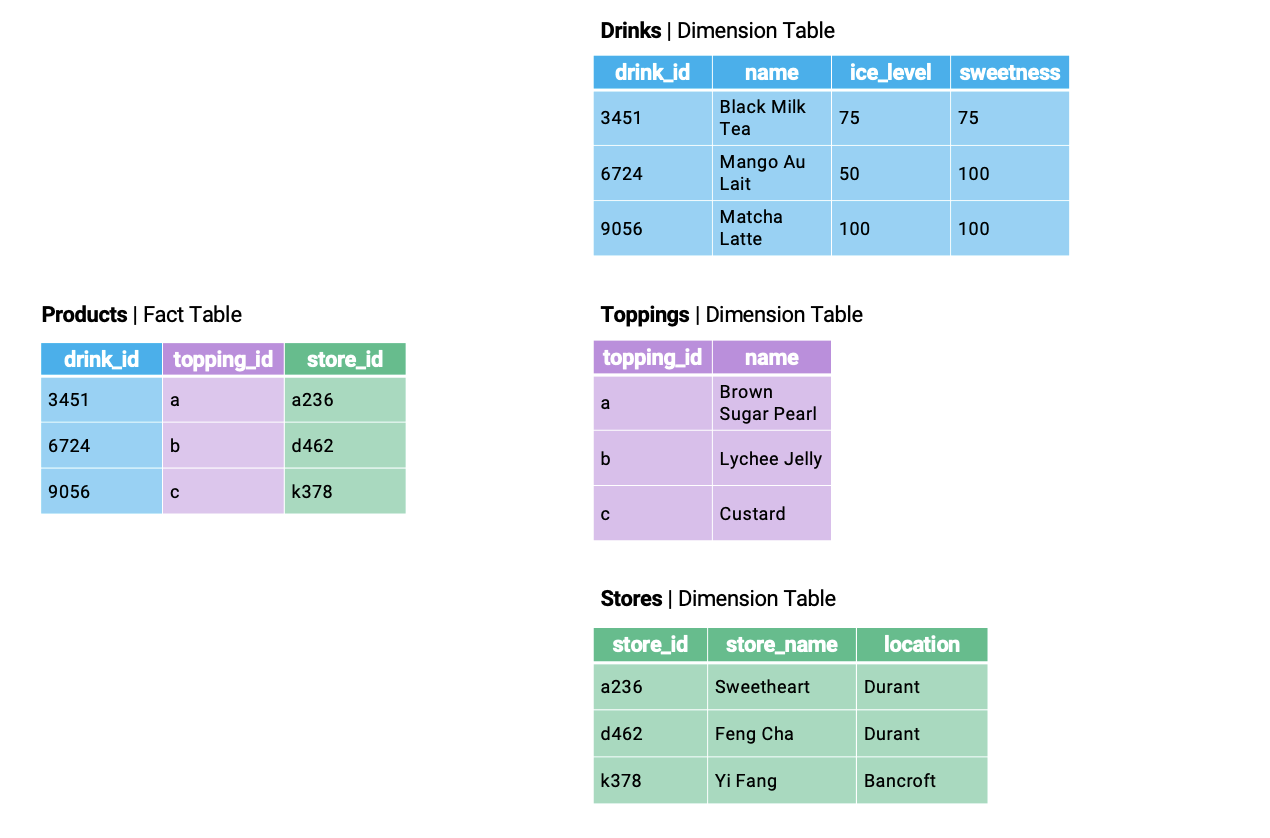

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **Why doing this?**

- Initially, you may store data like this:

| **time** | **drink** | **sweetness** | **topping** | **store** | **location** | **quantity** | **price** |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 10:01 | Matcha Latte | 100 | Custard | Yi Fang | Bancroft | 2 | 12 |
| 10:03 | Matcha Latte | 100 | Custard | Yi Fang | Bancroft | 1 | 6 |
| 10:05 | Matcha Latte | 100 | Custard | Yi Fang | Bancroft | 3 | 18 |

- It is fine when the volume is not huge

- But you may have millions of transaction later on, then you **may store the redundant information multiple times** (e.g. Yi Fang, Custard etc.)

- A better way to record is to **break it down to basic elements** instead of recording one complete sentence-like entry

**Waht elements should be picked? The ones are not changed and the ones change all the time!**

- Those 2 information should be spitted!
</div>

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- Usually we put **relatively stable data into dimensional tables**

- **Ad-hoc Data will be put into fact table** (but you can also think about put it into another dimensional table, so that there are 2 types of dimentional tables)

</div>

- If we explicitly mark the relationships between tables, we start to see the star-like structure of the star schema

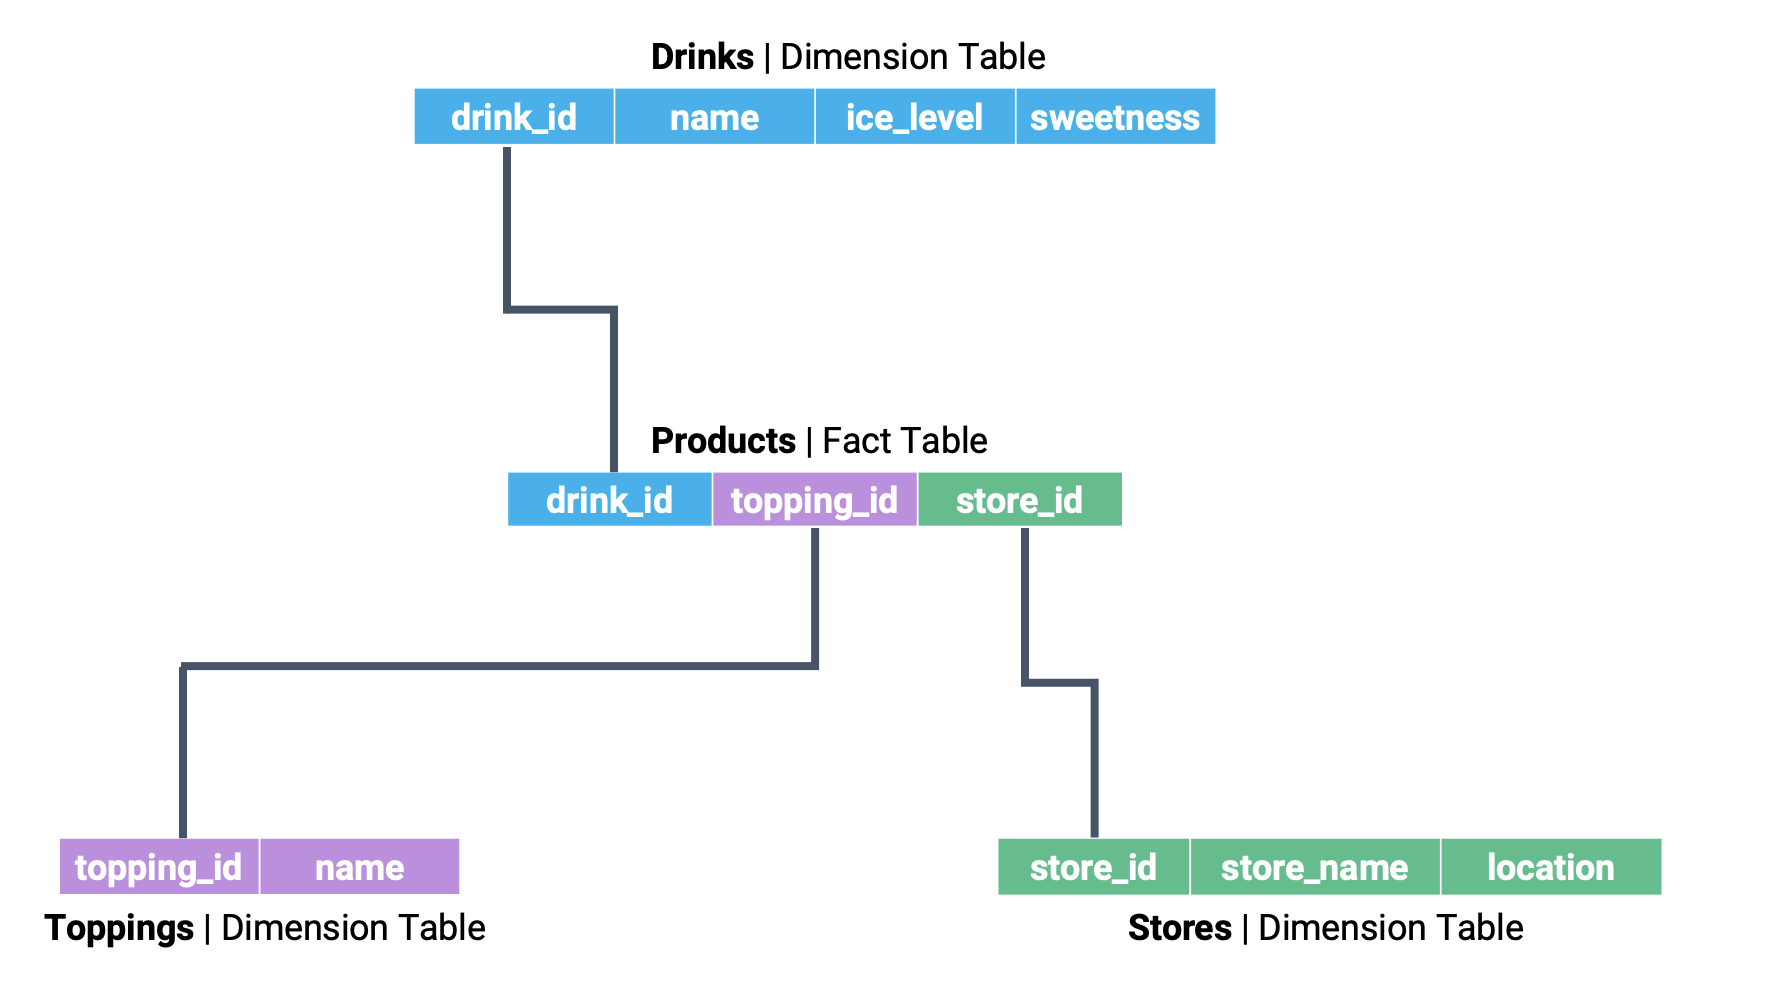

- To join data across multiple tables, we’ll use the `JOIN`

- We’ll make things easier for now by first considering the simpler `cats` dataset, which consists of the tables `s` and `t`

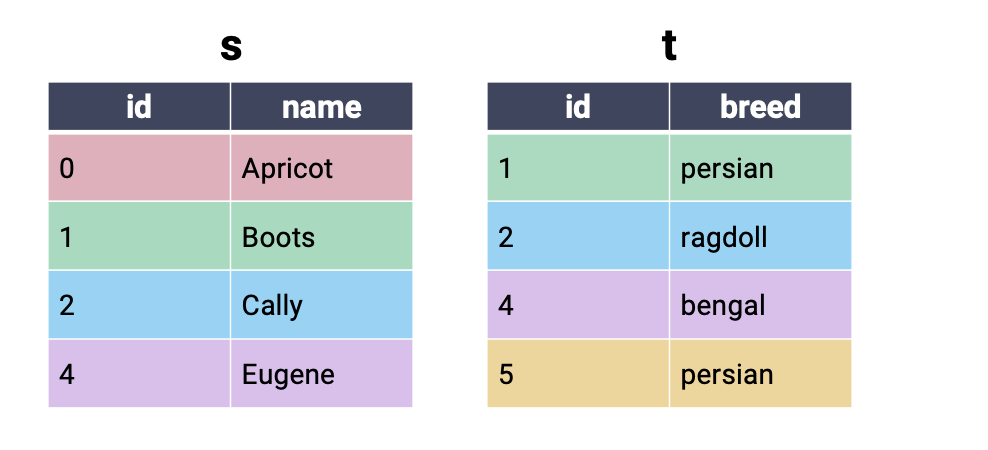

- To perform a join, we amend the `FROM` clause. You can think of this as saying, “`SELECT` my data `FROM` tables that have been `JOIN`ed together.”

In [ ]:
SELECT <column list>
FROM table_1 
    JOIN table_2 
    ON key_1 = key_2;

- We need to specify **which 2 cols is used as the matching key pairs**

- With all those provided, we can have many rules to combine 2 tables

### `INNER JOIN` / `JOIN`

- We start from the left table (It doesn't really matter. It works too even starting drom right)

- For each entry, we try to find the match from the right

	- If matched, keep both
	
	- If not, drop

- Entries from both left and right tables can be dropped

- It only keeps the overlapped part of 2 tables 

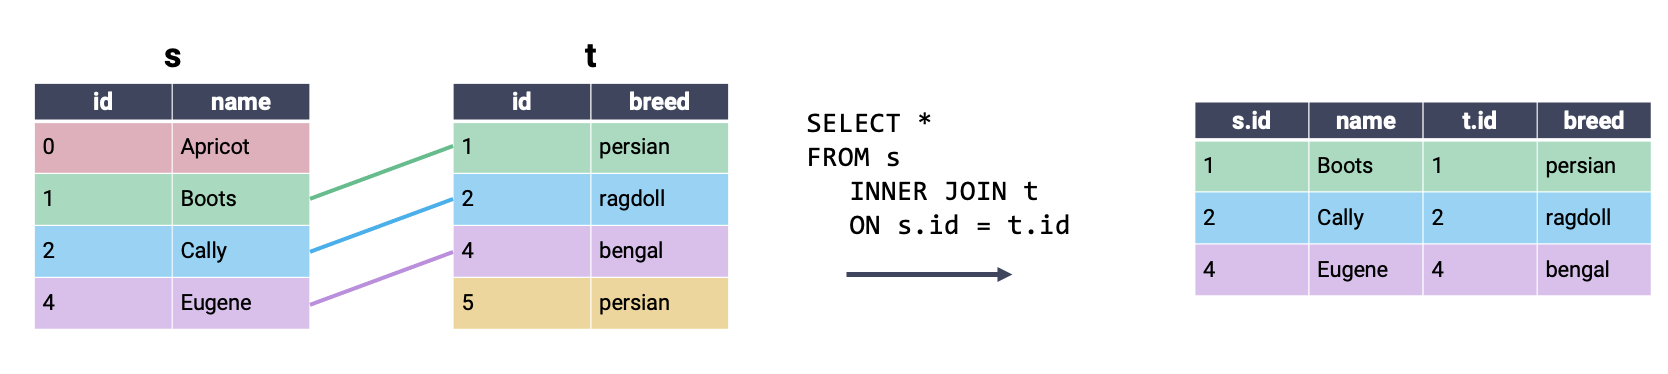

### `CROSS JOIN`

- Sometimes you don't want to drop any entry from both tables

- It can be viewed as the cartesian product of both tables

- Start from right table, for each row：

  - It matches `every` rows in the left table

- We can see that **it doesn't require a matching key pair**

- **It even doesn't involve any matching work!** It just put 2 tables together in some way 

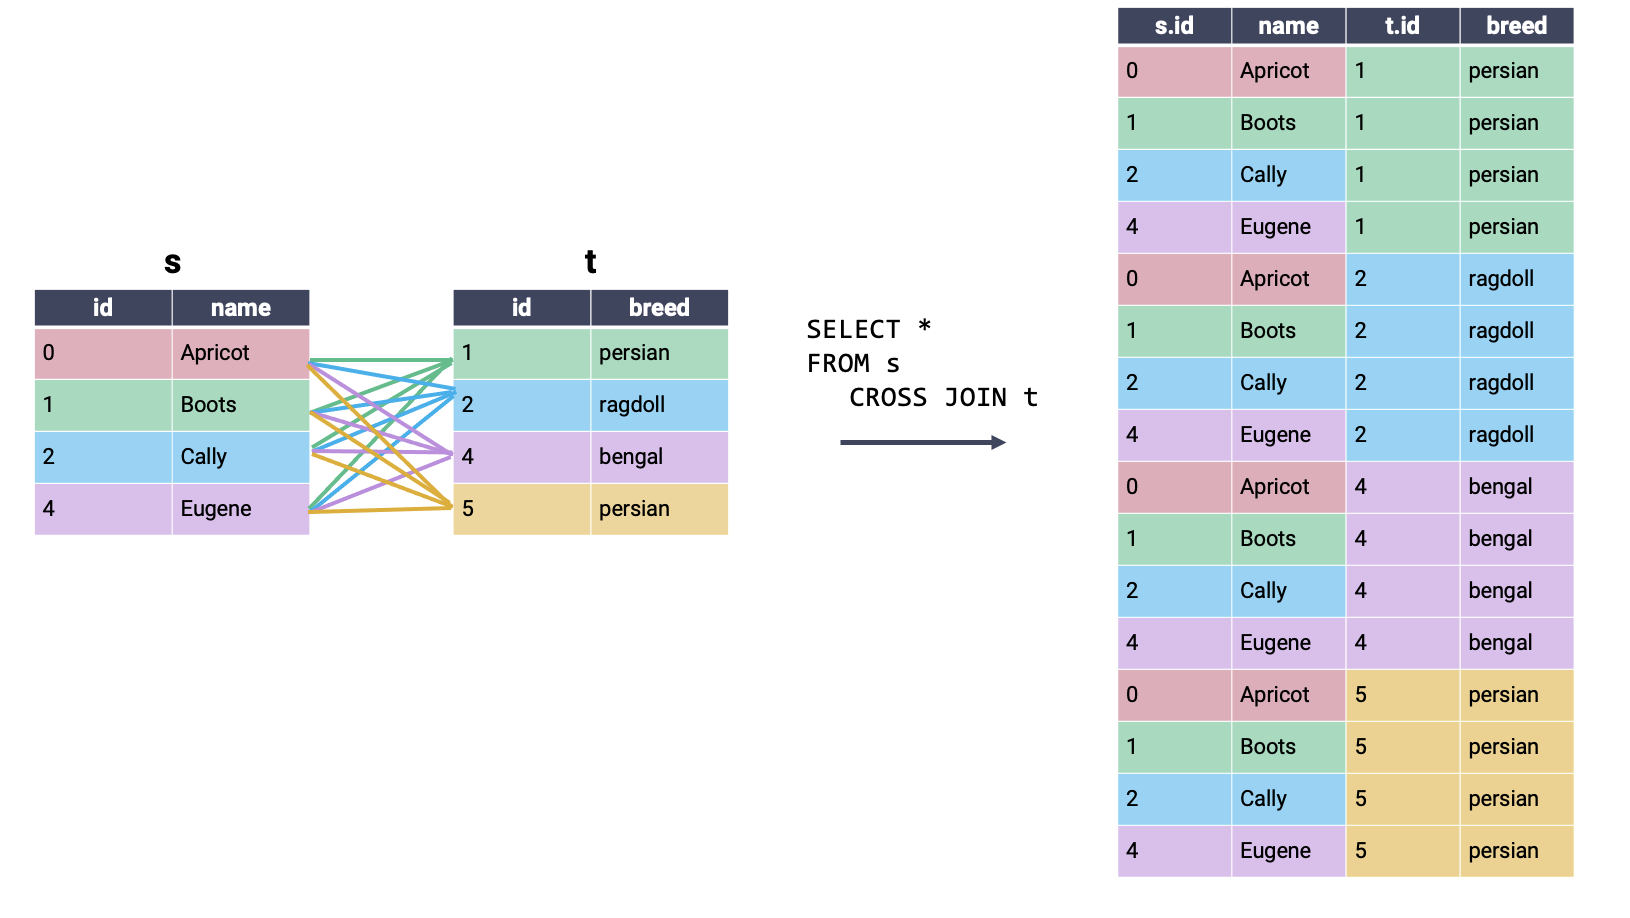

### `OUTER JOIN` (`LEFT` & `RIGHT` & `FULL`)

- Sometimes we may need to keep all the records of one table

- We use `OUTER JOIN`

**`LEFT JOIN`**

- All rows from the left table will be kept

- Start from left

- For each row
  
  - If there is a match in the right table, we keep them
  
  - If no matches, we keep the left and put `NULL` on the right

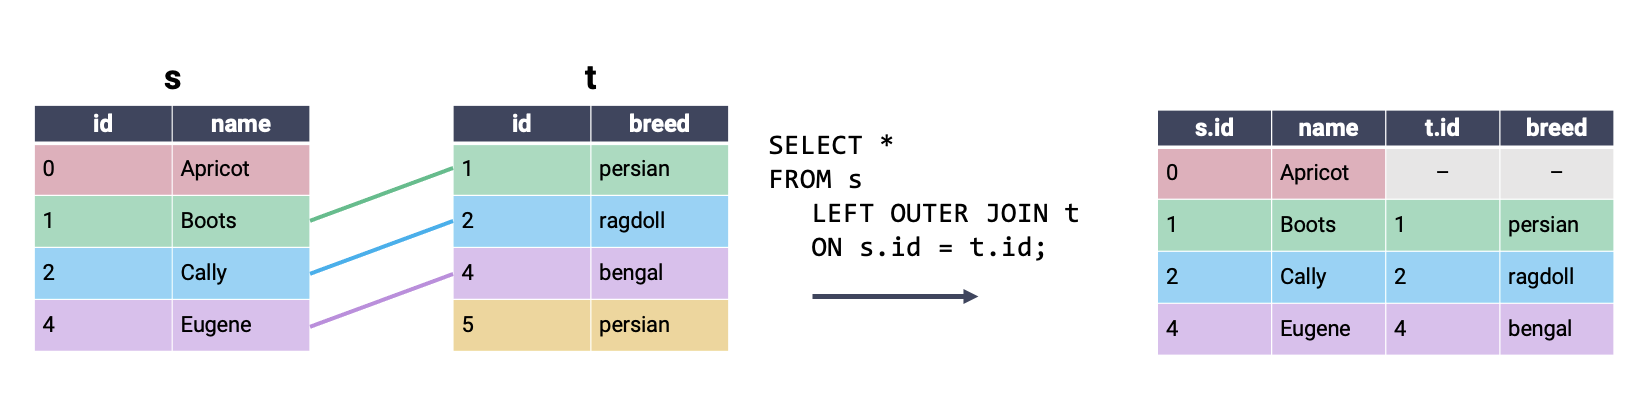

**`RIGHT JOIN`**

- Similar logic, just start from the right table

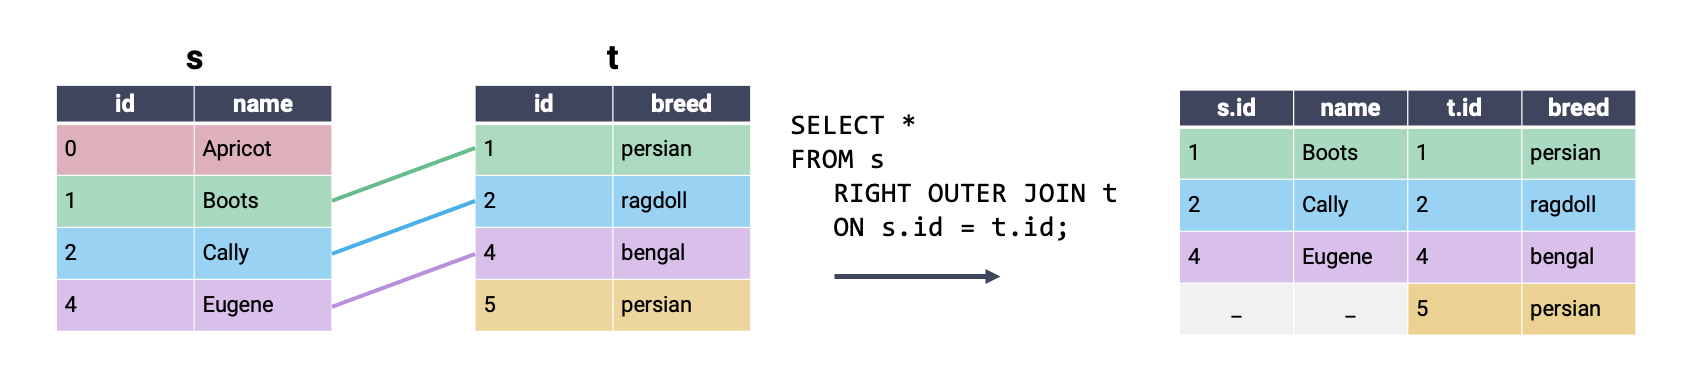

**`FULL JOIN`**

- What if we still want to keep all records for both tables

- But you don't want to use `CROSS JOIN` (too many redundant rows and it does no matching job)

- **We can first do a `LEFT JOIN` then do a `RIGHT JOIN`**

	- `LEFT JOIN` works the same way **top-down**
	
	- `RIGHT JOIN` works **bottom-up** in a slightly different way
    	
		- If match, it ignores
		
		- If not, put in a `NULL`

- Since it involves matching, we need to provide with a match key pair

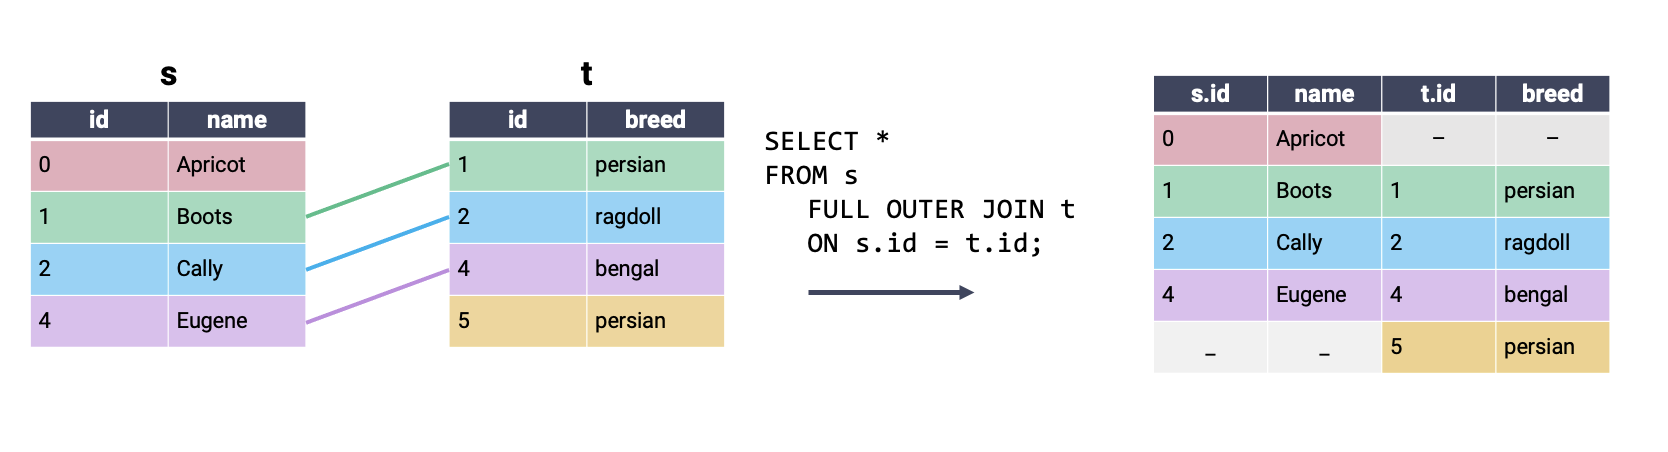

### Aliasing in `JOIN`s

- Sometimes we don't want to spell the whole names for tables when coding the match key pair part

- We want to make it convenient to refer so we use alias here too

- It is the same as what we do to cols, we use `AS`

In [ ]:
%%sql

SELECT primaryTitle, averageRating
FROM Title AS T INNER JOIN Rating AS R # We give aliases here
ON T.tconst = R.tconst; # So we don't need to code the complete names here

Running query in 'imdb'

primaryTitle,averageRating
Miss Jerry,5.300000190734863
The Corbett-Fitzsimmons Fight,5.199999809265137
Bohemios,4.199999809265137
The Story of the Kelly Gang,6.0
The Prodigal Son,5.400000095367432
Robbery Under Arms,4.300000190734863
Hamlet,2.9000000953674316
Don Quijote,4.199999809265137
The Fairylogue and Radio-Plays,5.099999904632568
Faldgruben,4.400000095367432


- `AS` is acutally optional. So you can also code in this way

In [58]:
%%sql

SELECT primaryTitle, averageRating
FROM Title T INNER JOIN Rating R
ON T.tconst = R.tconst;

Running query in 'imdb'

primaryTitle,averageRating
Miss Jerry,5.300000190734863
The Corbett-Fitzsimmons Fight,5.199999809265137
Bohemios,4.199999809265137
The Story of the Kelly Gang,6.0
The Prodigal Son,5.400000095367432
Robbery Under Arms,4.300000190734863
Hamlet,2.9000000953674316
Don Quijote,4.199999809265137
The Fairylogue and Radio-Plays,5.099999904632568
Faldgruben,4.400000095367432


## 5 Common Table Expressions (CTEs)

- The queries can be complex when we encounter complicated problems

- We may want to **break it down to parts** instead of write one long complete code

- We may **create temporary tables** to achieve this

In [ ]:
WITH 
table_name1 AS ( 
    SELECT ...
),
table_name2 AS ( 
    SELECT ...
)
SELECT ... 
FROM 
table_name1, 
table_name2, ...

- By doing this, we can first extract separate data we need and give them names

- So we can refer them back when actual coding the "main query" below

**e.g.**

- Let’s say we want to identify the top 10 action movies that are:

  - Highly rated (with an average rating greater than 7)
  
  - Popular (having more than 5000 votes)
  
  - The primary actors who are the most popular

- We may filter to find good action movies and prolific actors separately

- In our final join, we only need to change the order

In [59]:
%%sql

WITH 
good_action_movies AS (
    SELECT *
    FROM Title T JOIN Rating R ON T.tconst = R.tconst  
    WHERE genres LIKE '%Action%' AND averageRating > 7 AND numVotes > 5000
),
prolific_actors AS (
    SELECT N.nconst, primaryName, COUNT(*) as numRoles
    FROM Name N JOIN Principal P ON N.nconst = P.nconst
    WHERE category = 'actor'
    GROUP BY N.nconst, primaryName
)
SELECT primaryTitle, primaryName, numRoles, ROUND(averageRating) AS rating
FROM good_action_movies m, prolific_actors a, principal p
WHERE p.tconst = m.tconst AND p.nconst = a.nconst
ORDER BY rating DESC, numRoles DESC
LIMIT 10;

Running query in 'imdb'

primaryTitle,primaryName,numRoles,rating
Threat Level Midnight: The Movie,Steve Carell,51,10.0
Threat Level Midnight: The Movie,Steve Carell,51,10.0
Threat Level Midnight: The Movie,Rainn Wilson,36,10.0
Threat Level Midnight: The Movie,Ed Helms,36,10.0
Threat Level Midnight: The Movie,Ed Helms,36,10.0
Threat Level Midnight: The Movie,John Krasinski,28,10.0
Threat Level Midnight: The Movie,Craig Robinson,26,10.0
Threat Level Midnight: The Movie,Ricky Gervais,17,10.0
Threat Level Midnight: The Movie,Stephen Merchant,14,10.0
Threat Level Midnight: The Movie,Creed Bratton,12,10.0


<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- for complex problems

- Use `WITH` to extract data from tables first

- Then write the main query



</div>

---
[Reference](https://ds100.org/course-notes/sql-ii/)